In [1]:
import cfe

cfe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

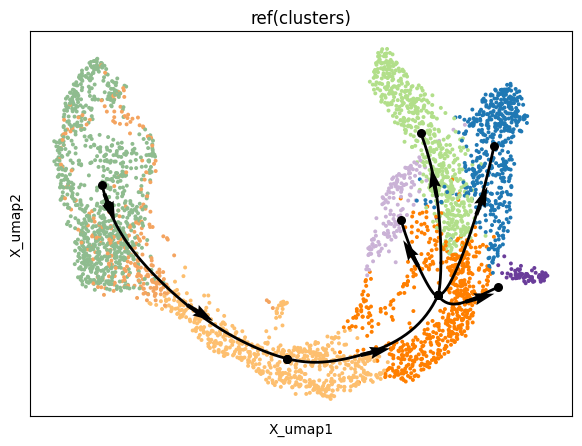

In [2]:
fadata = cfe.data.read_pancrease()
cfe.plot.plot_trajectory(fadata)
fadata

### 获得谱系从头到尾的里程碑序列

DEBUG    |- shortest path from 'Ductal' to 'Alpha': ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Alpha']                                                                                 
DEBUG    |- shortest path from 'Ductal' to 'Beta': ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta']                                                                                   
DEBUG    |- shortest path from 'Ductal' to 'Delta': ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Delta']                                                                                 
DEBUG    |- shortest path from 'Ductal' to 'Epsilon': ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Epsilon']                                                                             


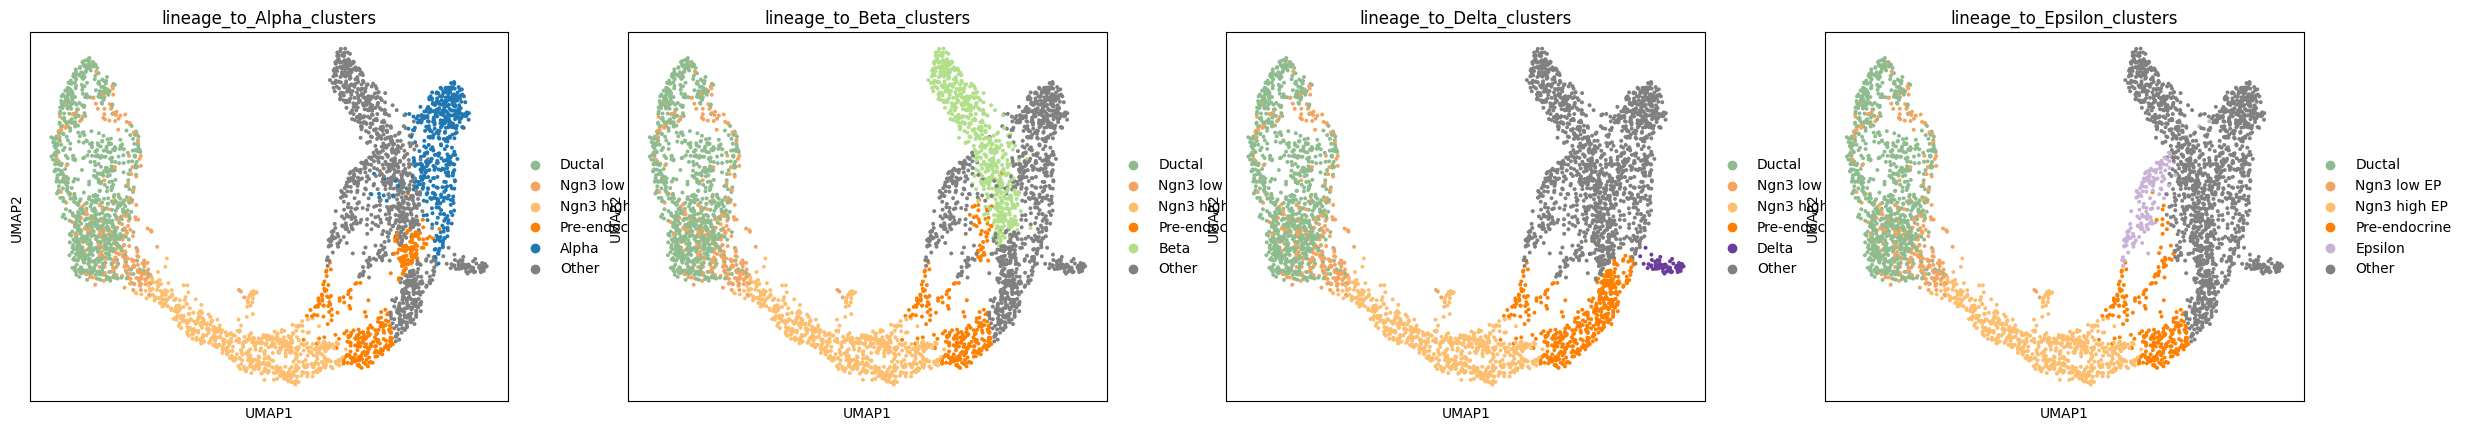

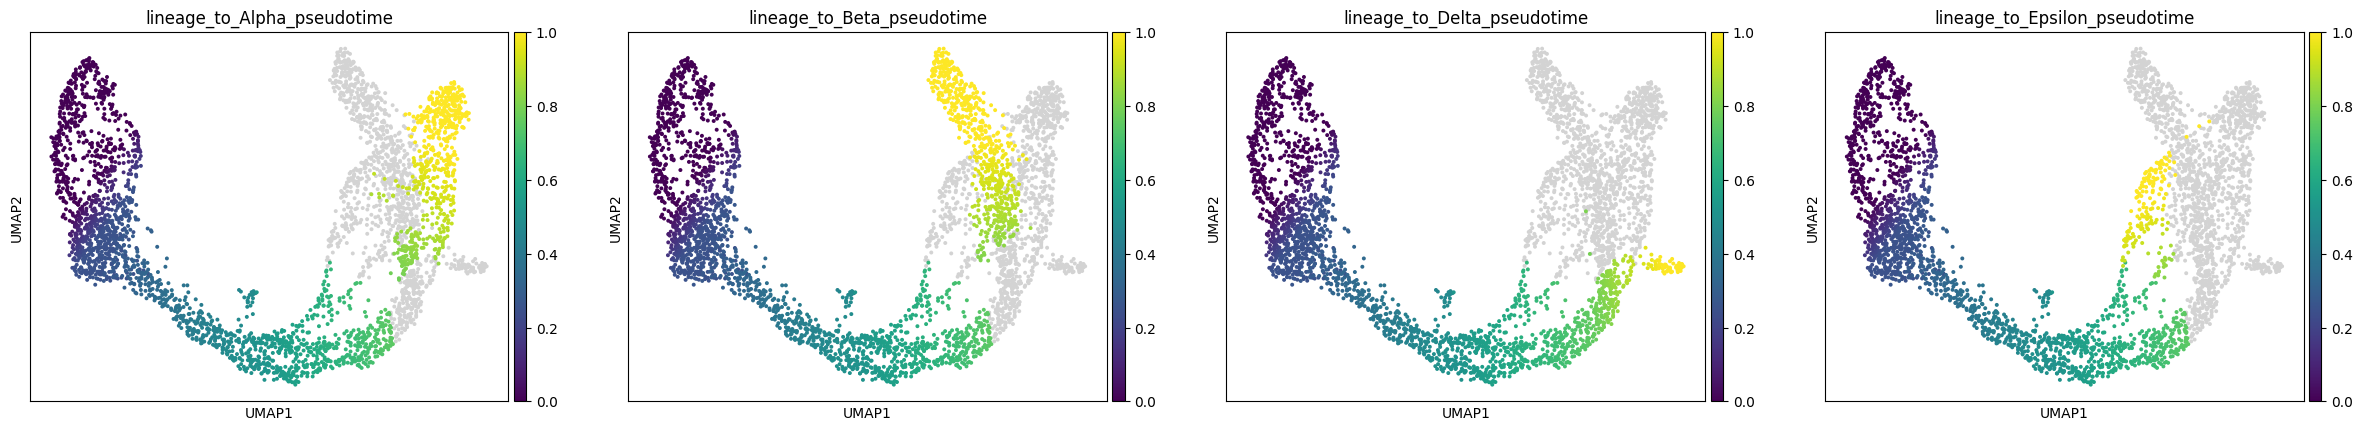

In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc

from sklearn.preprocessing import MinMaxScaler

logger = cfe.logger

# start, target milestones, cluster key
cluster_key = fadata.prior_information.get("cluster")
target_milestone_list = ["Alpha", "Beta", "Delta", "Epsilon"] # TODO: from prior information
start_cell = fadata.prior_information.get("start_cell")
start_milestone = fadata.get_start_milestone(start_cell)

# extract trajectory model to graph
model_name = "ref"
mw = fadata.get_milestone_wrapper(model_name=model_name)
is_directed = mw.milestone_network["directed"].any()
G = nx.from_pandas_edgelist(
    mw.milestone_network,
    source="from",
    target="to",
    create_using=nx.DiGraph if is_directed else nx.Graph,
)

# for each target milestone, extract lineage cells and visualize clusters along the lineage
lineage_key_list = [] # boolean key for lineage cells
lineage_pseudotime_key_list = [] # pseudotime
lineage_cluster_key_list = [] # cluster

for target_milestone in target_milestone_list:
    
    # find shortest path of start_milestone to target_milestone as lineage
    sp = nx.shortest_path(G, source=start_milestone, target=target_milestone, weight="length")
    spl_dict = {start_milestone: 0}
    for i in range(len(sp) - 1):
        spl_dict[sp[i+1]] = spl_dict[sp[i]] + G[sp[i]][sp[i+1]].get("length", 1)
    logger.debug(f"shortest path from '{start_milestone}' to '{target_milestone}': {sp}")
    # extract cells along the lineage
    df_list = []
    for i in range(len(sp) - 1):
        df = mw.progressions.query(f"`from` == '{sp[i]}' & `to` == '{sp[i+1]}'")
        df_list.append(df)
    lineage_progressions = pd.concat(df_list)
    lineage_cell_id_list = lineage_progressions['cell_id'].tolist()

    # add to adata.obs
    lineage_key = f"lineage_to_{target_milestone}"
    fadata.obs[lineage_key] = False
    fadata.obs.loc[lineage_cell_id_list, lineage_key] = True
    lineage_key_list.append(lineage_key)
    
    # pseudotime along the lineage
    lineage_pseudotime_key = f"{lineage_key}_pseudotime"
    fadata.obs.loc[lineage_cell_id_list, lineage_pseudotime_key] = 0
    spl_df = pd.DataFrame.from_dict(spl_dict, orient="index", columns=["distance"])
    def calculate_cell_pseudotime(cell_group):
        distances = spl_df.loc[cell_group["milestone_id"], "distance"]
        if distances.isnull().any():
            return np.nan
        percentages = cell_group["percentage"].values
        return (distances * percentages).sum()
    pseudotime_series = mw.milestone_percentages.query("cell_id in @lineage_cell_id_list").groupby("cell_id").apply(calculate_cell_pseudotime)
    pseudotime_series = pseudotime_series[lineage_cell_id_list] # sort
    fadata.obs.loc[lineage_cell_id_list, lineage_pseudotime_key] = MinMaxScaler().fit_transform(pd.DataFrame(pseudotime_series)).reshape(-1) # normalize to [0,1]
    lineage_pseudotime_key_list.append(lineage_pseudotime_key)
    
    # clusters along the lineage
    lineage_cluster_key = f"{lineage_key}_clusters"
    fadata.obs[lineage_cluster_key] = "Other" # default to Other
    fadata.obs.loc[lineage_cell_id_list, lineage_cluster_key] = fadata.obs.loc[lineage_cell_id_list, cluster_key].astype(str) # assign original cluster to lineage cells
    fadata.obs[lineage_cluster_key] = pd.Categorical(fadata.obs[lineage_cluster_key], categories=sp + ["Other"], ordered=True)
    old_cluster_dict = dict(zip(fadata.obs[cluster_key].cat.categories, fadata.uns[f"{cluster_key}_colors"]))
    new_cluster_dict = {"Other": "#808080"} # gray for other cells
    for k,v in old_cluster_dict.items():
        if k in sp:
            new_cluster_dict[k] = v
    fadata.uns[f"{lineage_cluster_key}_colors"] = [new_cluster_dict[i] for i in fadata.obs[lineage_cluster_key].cat.categories]
    lineage_cluster_key_list.append(lineage_cluster_key)

# visualize
sc.pl.umap(fadata, color=lineage_cluster_key_list)
sc.pl.umap(fadata, color=lineage_pseudotime_key_list)

TODO: 进行轨迹比对G2G(看看轨迹比对需要什么数据呢？答：需要的是log后的基因表达值和伪时间)

In [35]:
import anndata as ad
import scvelo as scv

adata = ad.AnnData(X=fadata.X, obs=fadata.obs, var=fadata.var)
adata.obsm["X_umap"] = fadata.obsm["X_umap"] # only save umap embedding
adata.uns[f"{cluster_key}_colors"] = fadata.uns[f"{cluster_key}_colors"] # only save cluster colors
scv.pp.filter_and_normalize(adata, n_top_genes=2000)

del adata.var

for i in range(len(lineage_key_list)):
    lineage_key = lineage_key_list[i]
    lineage_pseudotime_key = lineage_pseudotime_key_list[i]
    lineage_cluster_key = lineage_cluster_key_list[i]
    adata_sub = adata[adata.obs[lineage_key], :]
    adata_sub.obs = adata_sub.obs[[lineage_pseudotime_key, lineage_cluster_key]]\
        .rename(columns={lineage_pseudotime_key: "pseudotime", lineage_cluster_key: "clusters"})
    filename = f"./tmp/downstream_lineage_dev/pancreas-ref-{lineage_key}.h5ad"
    adata_sub.write_h5ad(filename)
    logger.debug(f"write '{lineage_key}' to {filename} \n: {adata_sub}")
    

Extracted 2000 highly variable genes.
Logarithmized X.
DEBUG    |- write 'lineage_to_Alpha' to ./tmp/downstream_lineage_dev/pancreas-ref-lineage_to_Alpha.h5ad                                                                                                 
         : AnnData object with n_obs × n_vars = 2623 × 2000                                                                                                                                             
             obs: 'pseudotime', 'clusters'                                                                                                                                                              
             uns: 'clusters_colors', 'log1p'                                                                                                                                                            
             obsm: 'X_umap'                                                                                                                  

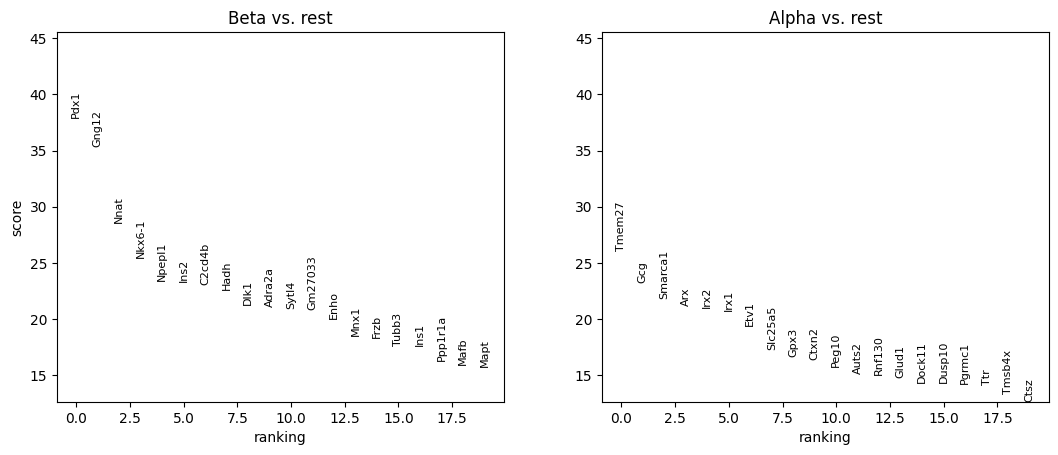

In [16]:
adata_sub = adata[adata.obs.query("clusters in ['Alpha', 'Beta']").index, :]
sc.tl.rank_genes_groups(adata_sub, groupby="clusters")
sc.pl.rank_genes_groups(adata_sub)

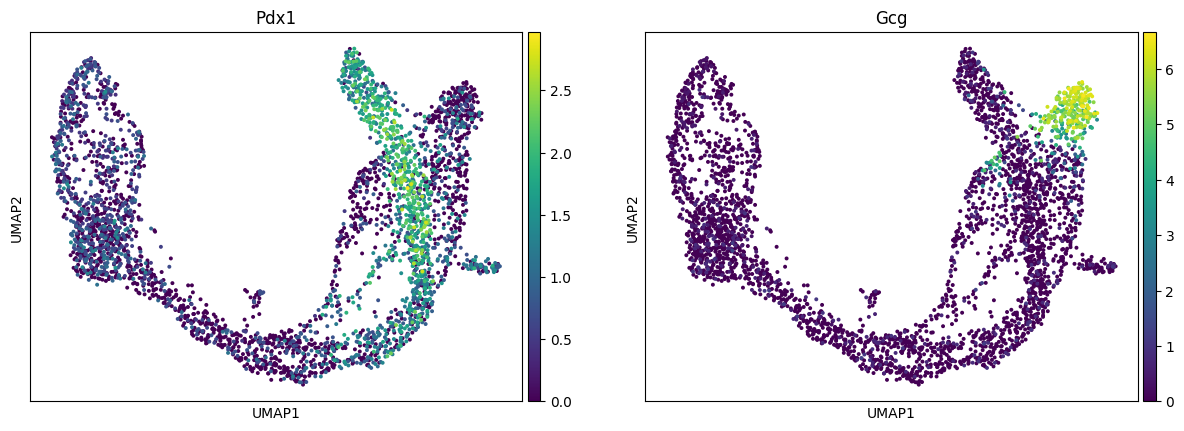

In [21]:
marker_gene_list = ["Pdx1", "Gcg"]
sc.pl.umap(adata, color=marker_gene_list)

## TODO: 指定分支点的里程碑路径，方便进行分支点的差异表达分析或BEAM Analysis

In [7]:
branch_point = ""

# extract trajectory model to graph
model_name = "ref"
mw = fadata.get_milestone_wrapper(model_name=model_name)
is_directed = mw.milestone_network["directed"].any()
G = nx.from_pandas_edgelist(
    mw.milestone_network,
    source="from",
    target="to",
    create_using=nx.DiGraph if is_directed else nx.Graph,
)

# choose branch point base on milestone degree centrality, such as degree > 2
branch_point_list = []
for k, v in G.degree():
    if v > 2:
        branch_point_list.append(k)
branch_point_list
branch_point = branch_point_list[0]
logger.info(f"chosen branch point: {branch_point}")

# extract 

INFO     |- chosen branch point: Pre-endocrine                                                                                                                                                          
